# Load Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pickle
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import matthews_corrcoef, make_scorer, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from classical_data_processing import get_vectorized_data

# Import Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_vectorized_data()

In [3]:
class_names = pd.read_csv("../data/class_names.csv", index_col=0).to_numpy()
class_names

array([['Irrelevant'],
       ['Negative'],
       ['Neutral'],
       ['Positive']], dtype=object)

# Model

In [4]:
knn = KNeighborsClassifier()
matthews_scorer = make_scorer(matthews_corrcoef)

## Hyperparameter Search

In [5]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"]
}

grid_search = GridSearchCV(knn, param_grid, scoring=matthews_scorer, verbose=3)
grid_search.fit(X_train, y_train)

grid_search.cv_results_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.911 total time=  23.1s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.915 total time=  21.4s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.920 total time=  20.6s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.925 total time=  20.4s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.931 total time=  20.9s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.921 total time=  22.1s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.927 total time=  20.6s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.931 total time=  21.2s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.936 total time=  20.5s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.948 total time=  20.7s
[CV 1/5] END ....n_neighbors=5, weights=uniform;, score=0.884 total time=  20.6s
[CV 2/5] END ....n_neighbors=5, weights=uniform;

{'mean_fit_time': array([0.30186539, 0.29997416, 0.30033374, 0.30064292, 0.29162631,
        0.30534372, 0.31012087, 0.31593051, 0.30595498, 0.31169171,
        0.2691638 , 0.30102634]),
 'std_fit_time': array([0.00675058, 0.01394189, 0.01349443, 0.00369719, 0.01389808,
        0.00860055, 0.01700191, 0.04294519, 0.00714829, 0.01107744,
        0.00764759, 0.07522118]),
 'mean_score_time': array([21.07918215, 20.81069193, 20.45344753, 20.74939094, 20.55755086,
        20.56354051, 20.86114311, 21.59392586, 21.74686394, 25.46762104,
        21.0621172 , 20.79903464]),
 'std_score_time': array([0.99713909, 0.58762346, 0.22966629, 0.46671376, 0.09816509,
        0.09678348, 0.32335038, 1.609609  , 0.78523398, 1.80735038,
        0.39513217, 0.35018034]),
 'param_n_neighbors': masked_array(data=[3, 3, 5, 5, 7, 7, 9, 9, 11, 11, 13, 13],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False],
        fill_value=999999),
 'p

In [6]:
best_model = grid_search.best_estimator_

## Training

In [7]:
train_score = best_model.score(X_train, y_train)

print("Training Score: ", train_score)

Training Score:  0.9787090734736746


## Validation

In [8]:
val_score = best_model.score(X_val, y_val)

print("Validation Score: ", val_score)

Validation Score:  0.95


## Test

In [9]:
test_score = best_model.score(X_test, y_test)

print("Test Score: ", test_score)

Test Score:  0.966


# Display Results

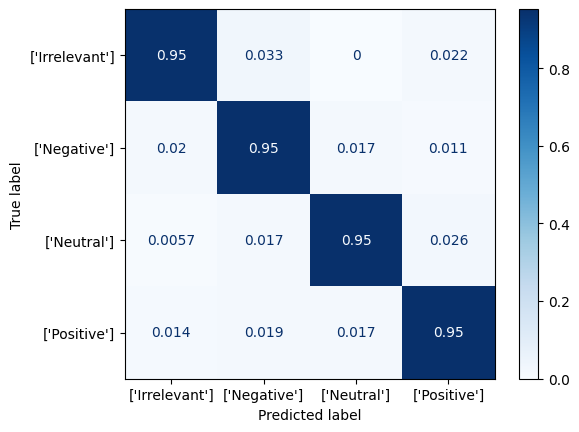

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
titles = [
    ("Confusion Matrix (without normalization)", None),
    ("Confusion Matrix (normalized)", "true")
]

display = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val,
    y_val,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize="true"
)

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = best_model.predict(X_test)

In [19]:
# MCC
matthews_corrcoef(y_test, y_pred)

np.float64(0.9542493886787352)

In [16]:
# PRECISION
precision_score(y_test, y_pred, average="macro")

0.9639271715105059

In [17]:
# RECALL
recall_score(y_test, y_pred, average="macro")

0.966965015594986

In [18]:
# F1 SCORE
f1_score(y_test, y_pred, average="macro")

0.9653452700127962